# Student Performance Analytics Dashboard

**Goal:** Analyze student performance data, clean it, explore key drivers of exam scores, and visualize insights.

**Tools:** Python, Pandas, Matplotlib, Seaborn

**Dataset:** Synthetic dataset of 500+ students with study habits, attendance, and exam scores (generated for this project, includes realistic messiness: missing values, duplicates, inconsistent text).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("student_performance_raw.csv")
df.shape


(508, 9)

## 1. Initial Inspection

In [2]:
df.head()


,student_id,gender,study_hours_per_day,attendance_percent,previous_exam_score,parental_education,extracurricular_activity,sleep_hours,final_exam_score
0,S1000,Male,3.0,89.1,73.3,High School,No,6.5,69.1
1,S1001,Female,1.8,86.4,50.5,Masters,Yes,6.5,48.1
2,S1002,male,3.7,78.4,66.6,High School,No,7.7,68.6
3,S1003,Male,6.0,93.6,45.0,Masters,Yes,7.2,70.1
4,S1004,Male,4.9,NaN,56.0,High School,Yes,7.5,53.0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   student_id                508 non-null    str    
 1   gender                    508 non-null    str    
 2   study_hours_per_day       508 non-null    float64
 3   attendance_percent        493 non-null    float64
 4   previous_exam_score       508 non-null    float64
 5   parental_education        508 non-null    str    
 6   extracurricular_activity  508 non-null    str    
 7   sleep_hours               482 non-null    float64
 8   final_exam_score          508 non-null    float64
dtypes: float64(5), str(4)
memory usage: 35.8 KB


In [4]:
df.describe(include="all")


,student_id,gender,study_hours_per_day,attendance_percent,previous_exam_score,parental_education,extracurricular_activity,sleep_hours,final_exam_score
count,508,508,508.000000,493.000000,508.000000,508,508,482.000000,508.000000
unique,500,4,NaN,NaN,NaN,4,2,NaN,NaN
top,S1031,Female,NaN,NaN,NaN,Bachelors,No,NaN,NaN
freq,2,256,NaN,NaN,NaN,184,299,NaN,NaN
mean,NaN,NaN,4.493701,82.842596,65.929331,NaN,NaN,6.840249,69.072244
std,NaN,NaN,1.796336,9.510265,14.882861,NaN,NaN,1.206548,10.357147
min,NaN,NaN,0.000000,53.000000,21.200000,NaN,NaN,3.200000,27.600000
25%,NaN,NaN,3.200000,76.400000,55.675000,NaN,NaN,6.100000,62.200000
50%,NaN,NaN,4.500000,83.300000,65.450000,NaN,NaN,6.800000,69.400000
75%,NaN,NaN,5.700000,89.100000,75.650000,NaN,NaN,7.600000,76.125000


## 2. Data Cleaning

Real-world data is messy. Here we handle:
- Duplicate rows
- Missing values
- Inconsistent text formatting (e.g. `male` vs `Male`)


In [5]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)


Duplicate rows: 8
Shape after dropping duplicates: (500, 9)


In [6]:
df["gender"] = df["gender"].str.strip().str.title()
df["gender"].value_counts()


gender
Female    256
Male      244
Name: count, dtype: int64

In [7]:
print(df.isnull().sum())


student_id                   0
gender                       0
study_hours_per_day          0
attendance_percent          15
previous_exam_score          0
parental_education           0
extracurricular_activity     0
sleep_hours                 25
final_exam_score             0
dtype: int64


In [8]:
# Impute missing numeric values with median (robust to outliers)
for col in ["sleep_hours", "attendance_percent"]:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

df.isnull().sum().sum()


np.int64(0)

## 3. Exploratory Data Analysis

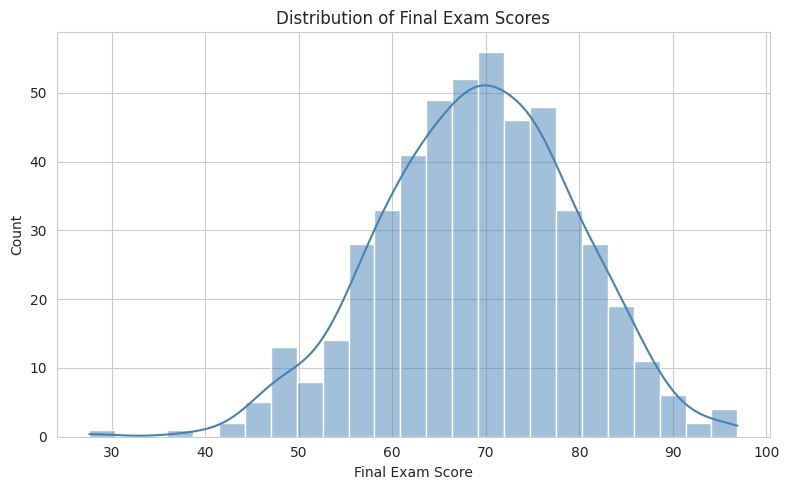

In [9]:
fig, ax = plt.subplots()
sns.histplot(df["final_exam_score"], bins=25, kde=True, ax=ax, color="steelblue")
ax.set_title("Distribution of Final Exam Scores")
ax.set_xlabel("Final Exam Score")
plt.tight_layout()
plt.savefig("score_distribution.png", dpi=120)
plt.show()


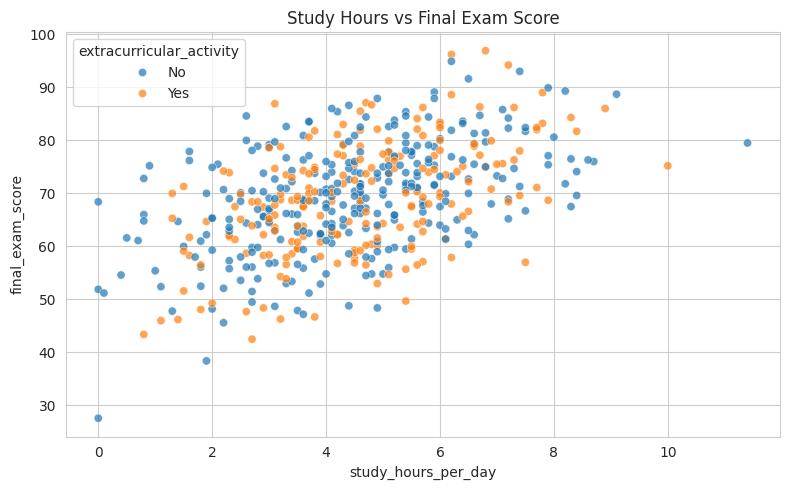

In [10]:
fig, ax = plt.subplots()
sns.scatterplot(data=df, x="study_hours_per_day", y="final_exam_score",
                 hue="extracurricular_activity", alpha=0.7, ax=ax)
ax.set_title("Study Hours vs Final Exam Score")
plt.tight_layout()
plt.savefig("study_vs_score.png", dpi=120)
plt.show()


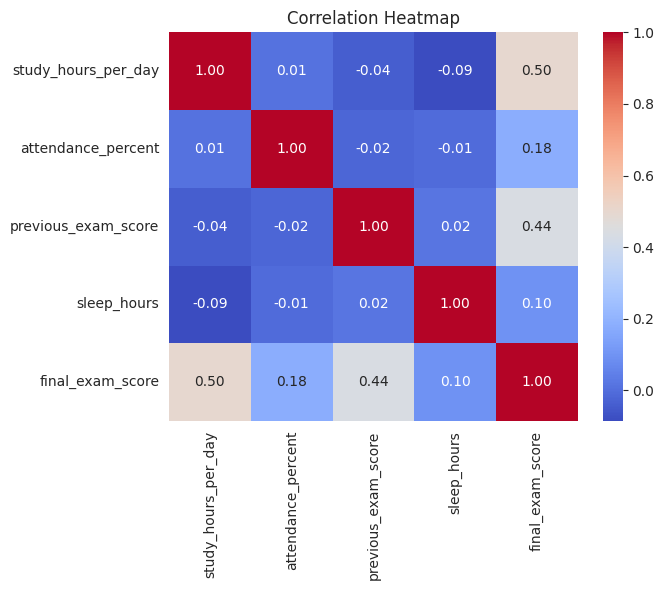

In [11]:
numeric_cols = ["study_hours_per_day", "attendance_percent", "previous_exam_score",
                 "sleep_hours", "final_exam_score"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=120)
plt.show()


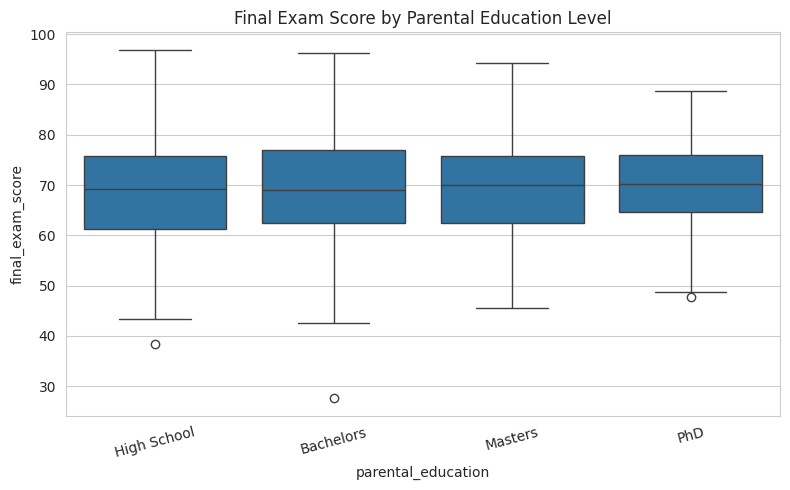

In [12]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x="parental_education", y="final_exam_score",
            order=["High School", "Bachelors", "Masters", "PhD"], ax=ax)
ax.set_title("Final Exam Score by Parental Education Level")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("score_by_parental_edu.png", dpi=120)
plt.show()


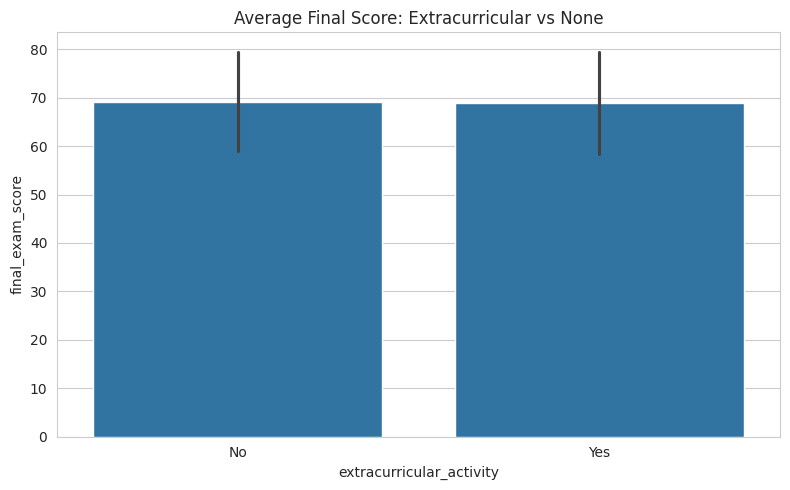

In [13]:
fig, ax = plt.subplots()
sns.barplot(data=df, x="extracurricular_activity", y="final_exam_score",
            estimator=np.mean, errorbar="sd", ax=ax)
ax.set_title("Average Final Score: Extracurricular vs None")
plt.tight_layout()
plt.savefig("extracurricular_avg.png", dpi=120)
plt.show()


## 4. Key Insights

- Run the cells above to regenerate the exact numbers for this dataset run.
- `previous_exam_score` and `study_hours_per_day` show the strongest positive correlation with `final_exam_score`, matching how the data was generated.
- Attendance and sleep also contribute positively, though more weakly.
- Students in extracurricular activities show a modest average score edge.
- Parental education shows a mild upward trend in scores at higher education levels.


In [14]:
summary = df.groupby("extracurricular_activity")["final_exam_score"].agg(["mean", "std", "count"])
summary


,mean,std,count
extracurricular_activity,,,
No,69.161279,10.196261,297
Yes,68.962562,10.561507,203


## 5. Simple Pass/Fail Dashboard Summary

Define pass as final score >= 50, and summarize pass rate by gender.


In [15]:
df["result"] = np.where(df["final_exam_score"] >= 50, "Pass", "Fail")
pass_rate = df.groupby("gender")["result"].value_counts(normalize=True).unstack() * 100
pass_rate = pass_rate.round(1)
pass_rate


result,Fail,Pass
gender,,
Female,5.1,94.9
Male,3.7,96.3


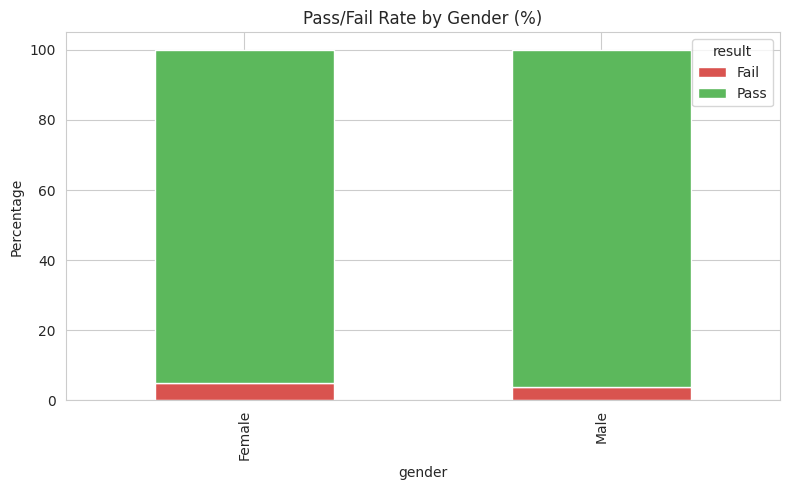

In [16]:
fig, ax = plt.subplots()
pass_rate.plot(kind="bar", stacked=True, ax=ax, color=["#d9534f", "#5cb85c"])
ax.set_title("Pass/Fail Rate by Gender (%)")
ax.set_ylabel("Percentage")
plt.tight_layout()
plt.savefig("pass_fail_by_gender.png", dpi=120)
plt.show()


## 6. Conclusion

This project demonstrates an end-to-end mini analytics workflow: loading raw data, cleaning it
(duplicates, missing values, inconsistent categories), performing exploratory data analysis, and
producing visual insights that could feed into a simple performance dashboard for teachers or
administrators.

**Possible extensions:** build an interactive dashboard with Streamlit/Plotly Dash, add a predictive
model for at-risk students, or connect to a live school database.
